# EDA & Modeling — Adult / Census Income Dataset

**Goal**: Classify whether a person earns **more than $50,000/year** (`>50K`) or not (`<=50K`).

Dataset: `sklearn.datasets.fetch_openml("adult", version=2)` — ~48,842 samples, 14 features, **mixed data types** (numerical + categorical) and **real missing values**.

---

## Teaching focus

This dataset is intentionally messier than Breast Cancer, because real-world data is messy. The four big themes:

1. Handling **mixed feature types** with a `ColumnTransformer`
2. Detecting and **imputing missing values**
3. Dealing with **class imbalance** and choosing appropriate metrics
4. Coping with **high-cardinality categorical features** (`native-country`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
from sklearn.datasets import fetch_openml

adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()

# The target is called "class" — rename for clarity
df = df.rename(columns={"class": "income"})

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  income          48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


**Observation**: Some columns are `object` / `category`, others are numerical. This is the typical real-world case — we need to handle the two types separately.

## 2. Initial cleanup

Two decisions we make up front:

1. **`fnlwgt`** is a sampling weight from the US Census Bureau — not a predictor. Drop it.
2. **`education`** (text) and **`education-num`** (number) encode the same information. We keep the numerical version (it's already ordinal, so no encoding needed) and drop the text version — otherwise the same information would enter the model twice.

In [4]:
df = df.drop(columns=["fnlwgt", "education"])
df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## 3. Missing values

In the Adult dataset, missing values are encoded as `?`. Pandas does not recognize this as NaN automatically — we have to convert it.

In [5]:
# Replace '?' with NaN (affects only object/category columns)
df = df.replace("?", np.nan)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nTotal share of rows with at least one missing value: {df.isna().any(axis=1).mean():.1%}")

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Total share of rows with at least one missing value: 7.4%


**Strategy**: We do **not** drop rows with missing values here. Instead, we'll impute them later inside the pipeline (`SimpleImputer`). This is the clean way to do it — statistics are computed per training fold during cross-validation, so test-fold information never leaks into the imputer.

## 4. Track column types

The most important separation for downstream preprocessing.

In [6]:
target = "income"

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols.remove(target)  # target is not a feature

print("Numerical features:")
print(" ", num_cols)
print("\nCategorical features:")
print(" ", cat_cols)

Numerical features:
  ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
  ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## 5. Target distribution

Adult is **noticeably imbalanced**.

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Share >50K: 23.9%


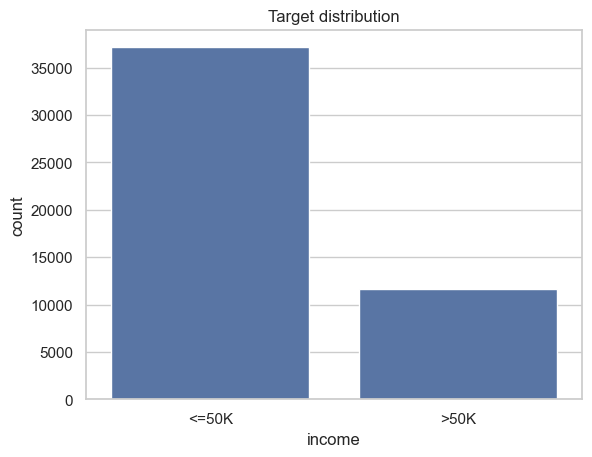

In [7]:
counts = df[target].value_counts()
print(counts)
print(f"\nShare >50K: {counts['>50K'] / counts.sum():.1%}")

sns.countplot(x=target, data=df, order=["<=50K", ">50K"])
plt.title("Target distribution")
plt.show()

**Consequence**: A baseline that always predicts `<=50K` already achieves ~76% accuracy. Accuracy alone is useless here — we need **precision, recall, F1, and ROC-AUC** to tell models apart.

## 6. EDA — Numerical features

In [8]:
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.64,13.71,17.0,28.0,37.0,48.0,90.0
education-num,48842.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.07,7452.02,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.50,403.00,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.42,12.39,1.0,40.0,40.0,45.0,99.0


<Axes: ylabel='Frequency'>

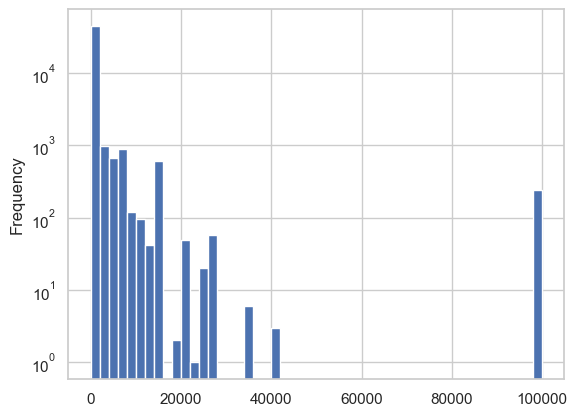

In [9]:
df["capital-gain"].plot(kind="hist", bins=50, logy=True)

**Observation**: `capital-gain` and `capital-loss` are extremely right-skewed — most rows are zero, a few are very large. Value ranges differ → scaling is required for distance-based and linear models.

**Quick primer on `capital-gain` / `capital-loss`**: These are US tax-return concepts — profits and losses from selling investments (stocks, real estate other than the primary home, etc.). About 91% of people in this dataset report `capital-gain = 0` and 95% report `capital-loss = 0` — only wealthier households tend to have non-zero values. That's exactly what makes the feature predictive of `>50K`, despite the many zeros.

<Axes: ylabel='Frequency'>

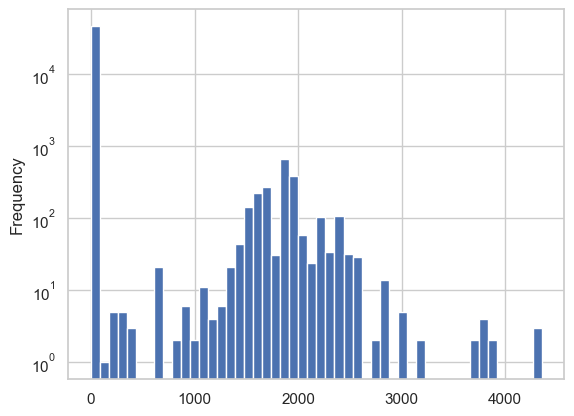

In [10]:
df["capital-loss"].plot(kind="hist", bins=50, logy=True)

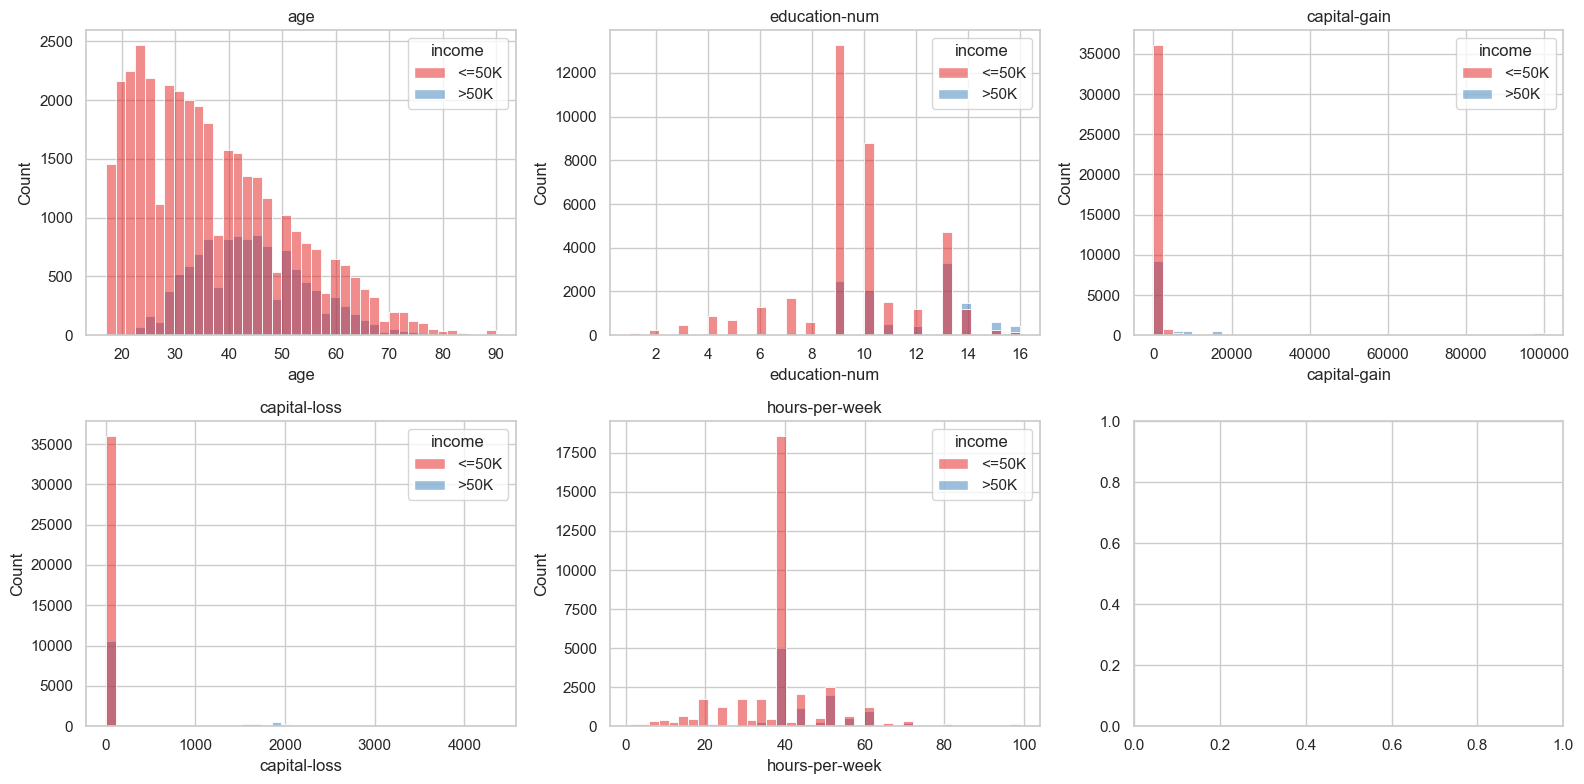

In [11]:
# Histograms of the numerical features, colored by target
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=df, x=col, hue=target, bins=40, ax=ax, palette="Set1", kde=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

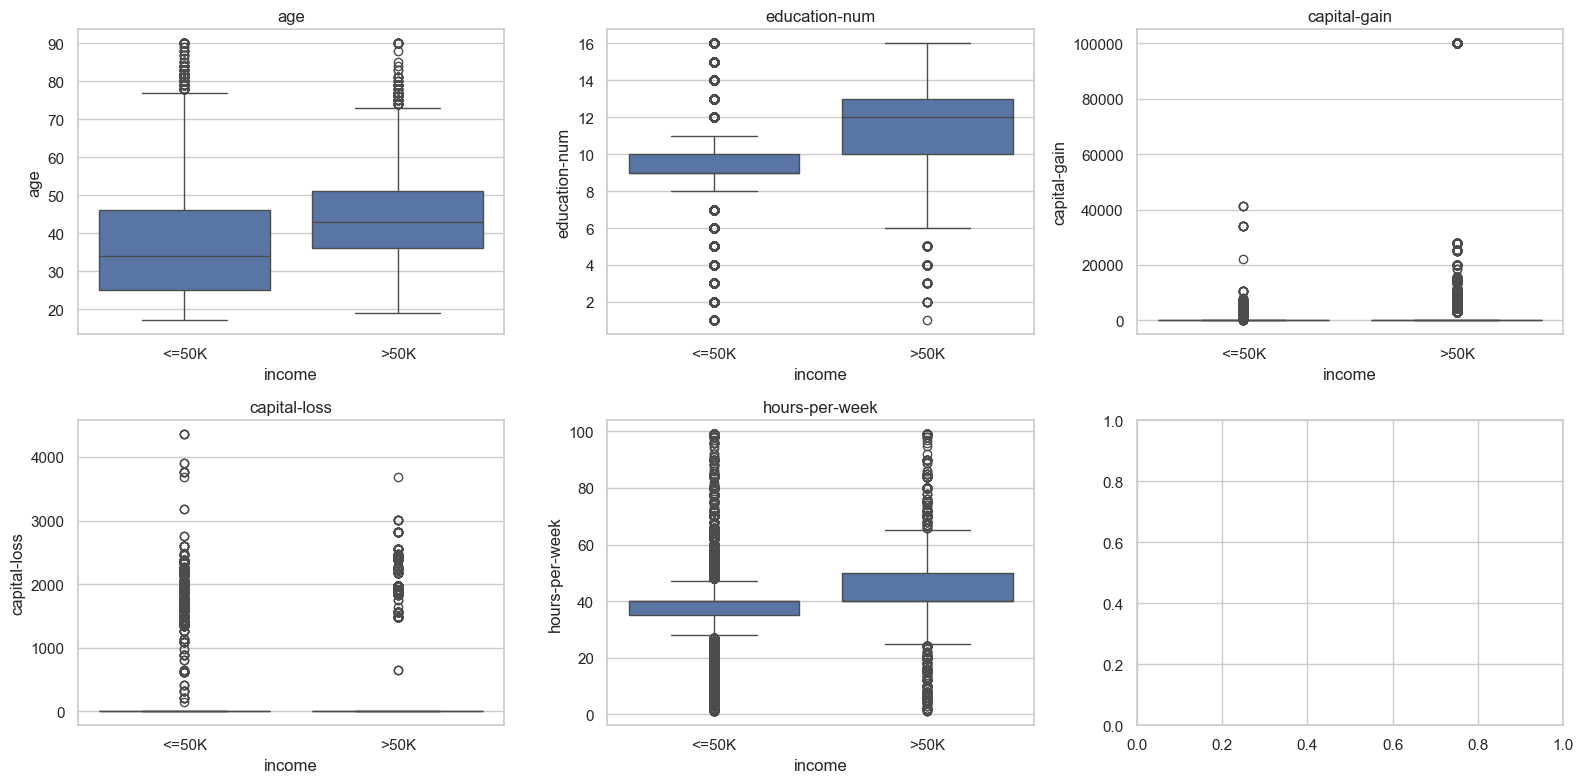

In [12]:
# Boxplots: numerical features vs. target
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax, order=["<=50K", ">50K"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

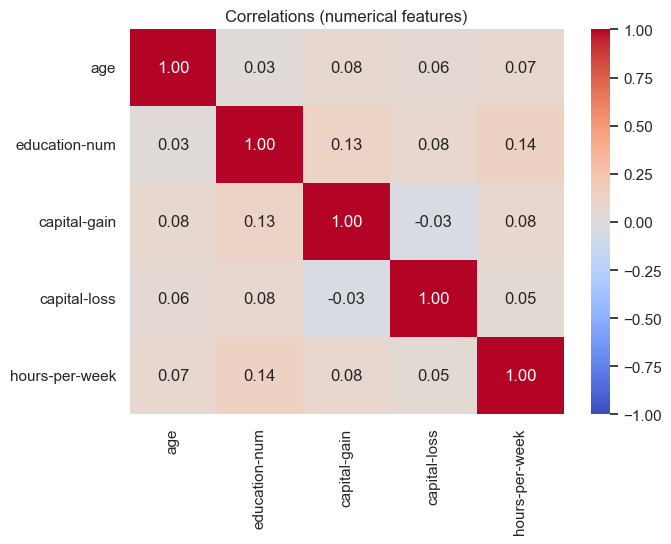

In [13]:
# Correlations among the numerical features
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlations (numerical features)")
plt.show()

## 7. EDA — Categorical features

Here we see the main tools for **categorical** variables: counts of each level, and the share of the positive class within each level.

In [14]:
# Number of unique values per categorical column
for col in cat_cols:
    print(f"{col:20s} {df[col].nunique():3d} unique values")

workclass              8 unique values
marital-status         7 unique values
occupation            14 unique values
relationship           6 unique values
race                   5 unique values
sex                    2 unique values
native-country        41 unique values


**`native-country` has ~40 unique values** — very unevenly distributed (the US dominates). This is *high cardinality* and can cause trouble later (lots of sparse one-hot columns, most rarely activated).

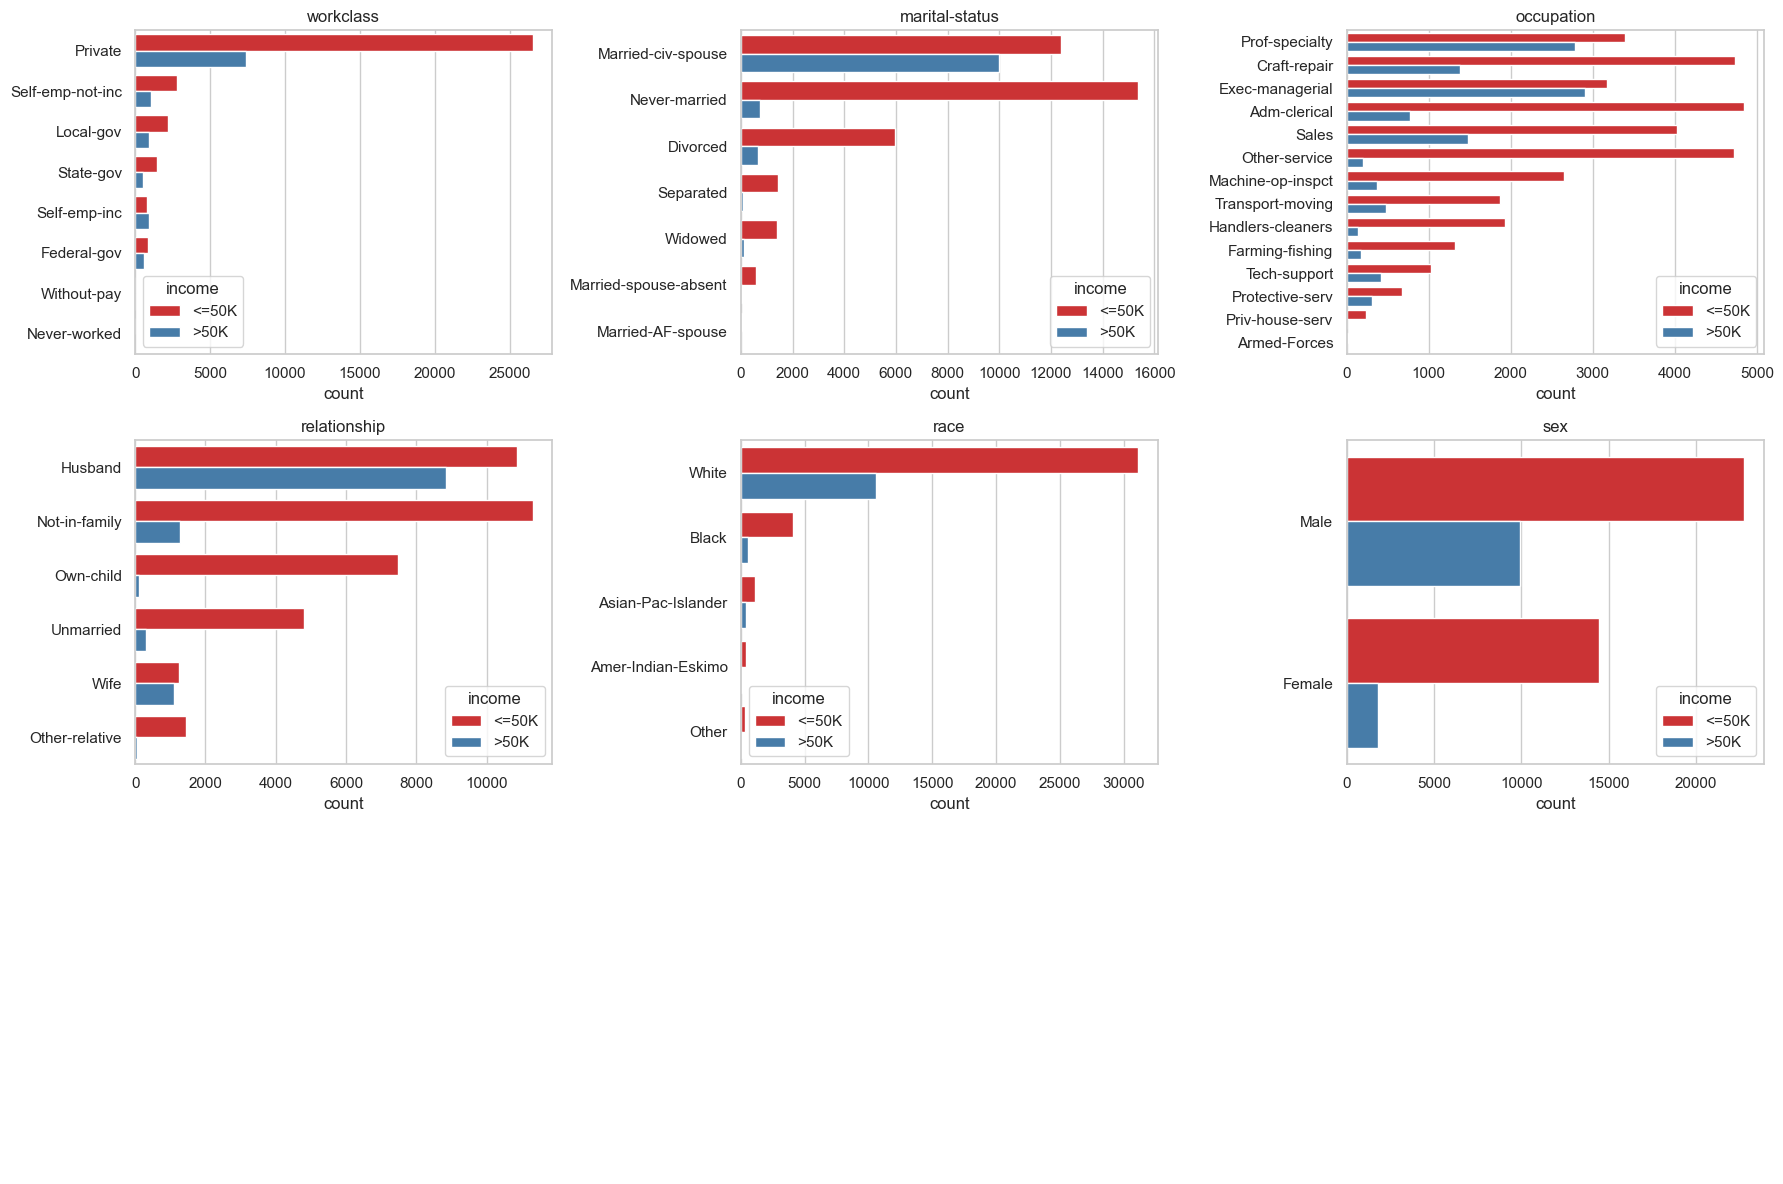

In [15]:
# Countplots of the categorical features (excluding native-country, which is too wide)
cat_to_plot = [c for c in cat_cols if c != "native-country"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, col in zip(axes.flat, cat_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue=target, order=order, ax=ax, palette="Set1")
    ax.set_title(col)
    ax.set_ylabel("")
for ax in axes.flat[len(cat_to_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Share of >50K within each category — shows which levels are most predictive
for col in ["sex", "marital-status", "occupation"]:
    ct = pd.crosstab(df[col], df[target], normalize="index").sort_values(">50K", ascending=False)
    print(f"\n=== {col} — share of >50K per level ===")
    print(ct.round(3))


=== sex — share of >50K per level ===
income  <=50K   >50K
sex                 
Male    0.696  0.304
Female  0.891  0.109

=== marital-status — share of >50K per level ===
income                 <=50K   >50K
marital-status                     
Married-civ-spouse     0.554  0.446
Married-AF-spouse      0.622  0.378
Divorced               0.899  0.101
Married-spouse-absent  0.908  0.092
Widowed                0.916  0.084
Separated              0.935  0.065
Never-married          0.955  0.045

=== occupation — share of >50K per level ===
income             <=50K   >50K
occupation                     
Exec-managerial    0.522  0.478
Prof-specialty     0.549  0.451
Armed-Forces       0.667  0.333
Protective-serv    0.687  0.313
Tech-support       0.710  0.290
Sales              0.732  0.268
Craft-repair       0.774  0.226
Transport-moving   0.796  0.204
Adm-clerical       0.863  0.137
Machine-op-inspct  0.877  0.123
Farming-fishing    0.884  0.116
Handlers-cleaners  0.933  0.067
Other-ser

In [17]:
# native-country separately: top 15 by frequency, plus share of >50K
nc_top = df["native-country"].value_counts().head(15).index
ct = pd.crosstab(
    df.loc[df["native-country"].isin(nc_top), "native-country"],
    df.loc[df["native-country"].isin(nc_top), target],
    normalize="index",
).sort_values(">50K", ascending=False)
ct.round(3)

income,<=50K,>50K
native-country,,
India,0.589,0.411
England,0.630,0.370
Canada,0.654,0.346
Italy,0.676,0.324
China,0.705,0.295
Philippines,0.712,0.288
Germany,0.718,0.282
Cuba,0.754,0.246
United-States,0.756,0.244


---
## 8. Preprocessing pipeline

Now we need **two branches** in the `ColumnTransformer`:

- **Numerical**: impute with median → standardize
- **Categorical**: impute with most-frequent value → one-hot encode

Putting the imputers *inside* the pipeline (rather than imputing the whole dataframe up front) is what prevents data leakage during cross-validation.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

prep = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

## 9. Train/test split

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = (df[target] == ">50K").astype(int)  # 1 = >50K, 0 = <=50K

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train share of positive class:", round(y_train.mean(), 3))

Train: (39073, 12) | Test: (9769, 12)
Train share of positive class: 0.239


## 10. Model comparison (cross-validation)

Because of the class imbalance, we focus on **ROC-AUC** and **F1** rather than accuracy.

In [20]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

models = {
    "KNN":              make_pipeline(prep, KNeighborsClassifier(n_neighbors=15)),
    "LogReg":           make_pipeline(prep, LogisticRegression(max_iter=2000, class_weight="balanced")),
    "DecisionTree":     make_pipeline(prep, DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    "RandomForest":     make_pipeline(prep, RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
    "GradientBoosting": make_pipeline(prep, GradientBoostingClassifier(random_state=42)),
    "Baseline (dummy)": make_pipeline(prep, DummyClassifier(strategy="most_frequent")),
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)
    rows.append({"model": name, **{m: cv[f"test_{m}"].mean() for m in scoring}})

results = pd.DataFrame(rows).set_index("model").round(3).sort_values("roc_auc", ascending=False)
results

/Users/bertram/Projects/github.com/b3rtram/uas_ml/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bertram/Projects/github.com/b3rtram/uas_ml/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bertram/Projects/github.com/b3rtram/uas_ml/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _

,accuracy,precision,recall,f1,roc_auc
model,,,,,
GradientBoosting,0.866,0.789,0.602,0.683,0.921
LogReg,0.806,0.563,0.848,0.677,0.905
KNN,0.846,0.709,0.606,0.653,0.893
RandomForest,0.844,0.686,0.638,0.661,0.892
DecisionTree,0.812,0.598,0.661,0.628,0.769
Baseline (dummy),0.761,0.000,0.000,0.000,0.500


**Note on `class_weight="balanced"`**: We penalize errors on the minority class more heavily. As a side effect, accuracy can drop below the dummy baseline — but precision/recall/F1 become more balanced. That's exactly the desired behavior when the minority class is the one we care about.

## 11. Confusion matrices

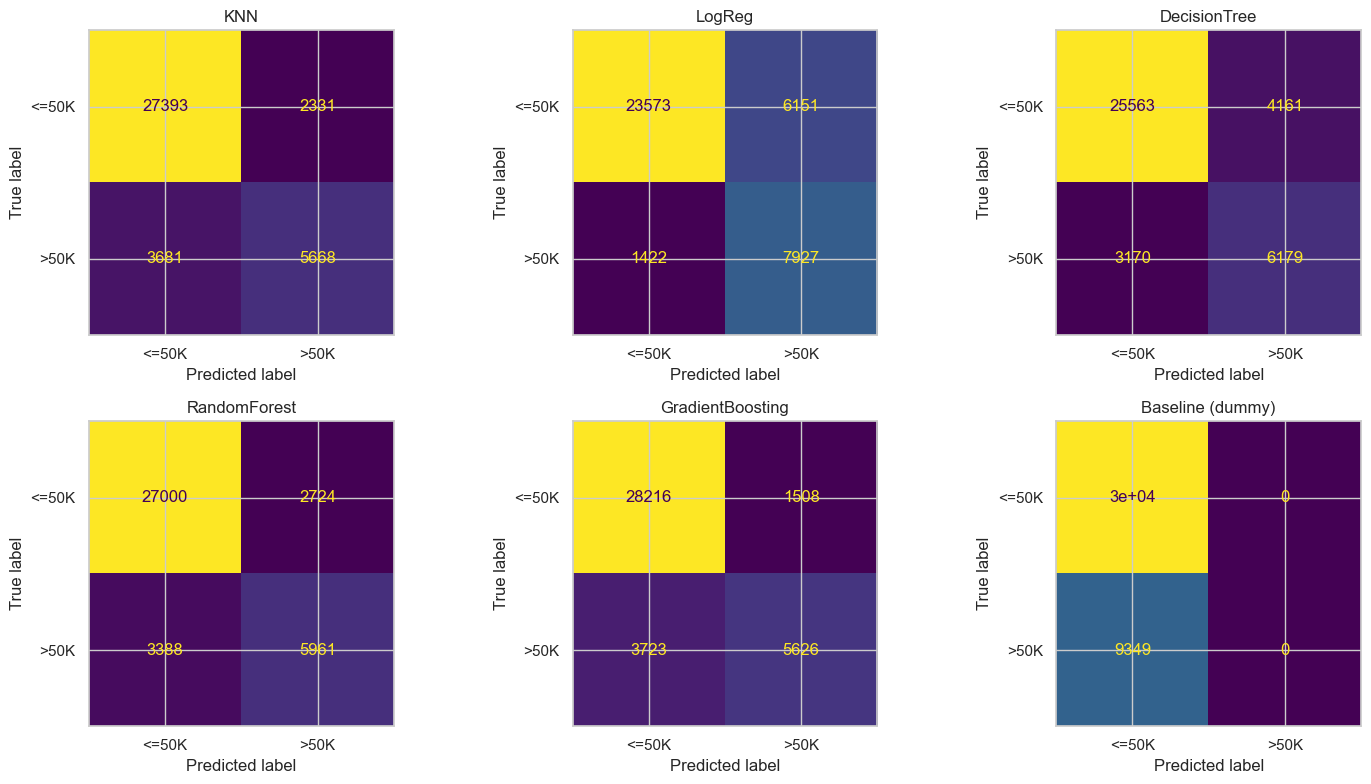

In [21]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, model) in zip(axes.flat, models.items()):
    y_pred = cross_val_predict(model, X_train, y_train, cv=5, n_jobs=-1)
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_pred,
        display_labels=["<=50K", ">50K"],
        ax=ax, colorbar=False,
    )
    ax.set_title(name)
for ax in axes.flat[len(models):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 12. Hyperparameter tuning (GridSearch for Gradient Boosting)

In [22]:
from sklearn.model_selection import GridSearchCV

gb_pipe = make_pipeline(prep, GradientBoostingClassifier(random_state=42))

param_grid = {
    "gradientboostingclassifier__n_estimators":  [100, 200],
    "gradientboostingclassifier__learning_rate": [0.05, 0.1],
    "gradientboostingclassifier__max_depth":     [3, 5],
}

grid_search = GridSearchCV(
    gb_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1,
)
grid_search.fit(X_train, y_train)

print("best params:    ", grid_search.best_params_)
print("best cv roc_auc:", round(grid_search.best_score_, 3))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
best params:     {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 5, 'gradientboostingclassifier__n_estimators': 200}
best cv roc_auc: 0.928


## 13. Final evaluation on the held-out test set

Test ROC-AUC: 0.929

              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      7431
        >50K       0.79      0.65      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



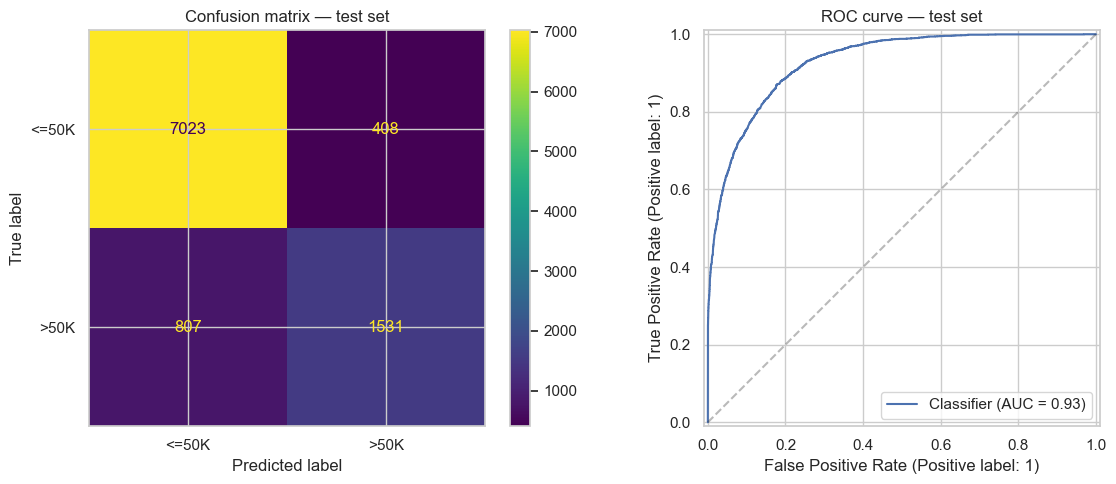

In [23]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

best = grid_search.best_estimator_
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["<=50K", ">50K"], ax=axes[0]
)
axes[0].set_title("Confusion matrix — test set")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC curve — test set")
plt.tight_layout()
plt.show()

## 14. Feature importance — the permutation method

To rank features by actual predictive power, we use **permutation importance**:

1. Compute the model's baseline score on the test set
2. Take one feature, **shuffle its values randomly** (breaking its link to the target)
3. Re-compute the score — the drop tells us how much the model relied on that feature
4. Repeat for every feature, several times, and average the score drops

**Why this is especially nice on the Adult dataset**:
- One-hot encoding splits one categorical column into many binary columns. `feature_importances_` would give one number per binary column — hard to read.
- Permutation importance shuffles the **original input column** (e.g. `marital-status` as a whole). You get one importance per real-world feature, exactly as you'd want for interpretation.

Works with any model (LogReg, SVM, Gradient Boosting, ...) — no need for a tree-based estimator.

In [ ]:
from sklearn.inspection import permutation_importance

# Note: this can take a minute on ~10k test rows with n_repeats=5
result = permutation_importance(
    best, X_test, y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc",
)

importances = pd.Series(
    result.importances_mean,
    index=X_test.columns,
).sort_values()

plt.figure(figsize=(8, 6))
importances.plot.barh()
plt.xlabel("Mean ROC-AUC drop when the feature is shuffled")
plt.title("Feature importance by permutation (test set)")
plt.tight_layout()
plt.show()

**Reading the chart**: each bar shows how much the test ROC-AUC drops when that feature's values get shuffled randomly. The longer the bar, the more the model relies on that feature.

**Expected pattern** (intuitive sanity check): `marital-status`, `education-num`, `capital-gain`, `age`, and `occupation` should top the chart — those are the features we already saw were strong in the EDA. Features like `race` or `native-country` typically show much smaller importance, partly because they are dominated by one majority value (so shuffling them mostly produces the same column).

**Note on uncertainty**: `result.importances_std` contains the standard deviation across the `n_repeats` shuffles — if it's large relative to the mean, that feature's importance is unstable. Worth printing alongside the means for any feature you actually want to interpret.

## 15. Outlook — what to try next

- **High cardinality** in `native-country`: group rare countries into `"Other"` (e.g. all with fewer than 100 occurrences) to shrink the one-hot space.
- **Feature engineering**: combine `capital-gain` and `capital-loss` into `capital-net`, or log-transform them to tame the long right tail.
- **Threshold tuning**: instead of `predict()` with the default 0.5 threshold, pick the threshold from the precision-recall curve based on what you care about (e.g. maximize recall at precision ≥ 0.6).
- **Fairness**: how does the model behave across the `sex` or `race` groups? Look into `fairlearn` for diagnostics like demographic parity and equalized odds.
- **Stronger gradient boosting**: try XGBoost, LightGBM, or CatBoost — the last one can even handle categorical features natively, no one-hot encoding required.